In [1]:
import pandas as pd
import numpy as np
from IPython.display import Image, HTML

In [204]:
df = pd.read_csv('amazon_specs_combined.csv')

In [57]:
df['category'].value_counts()

category
Office, Printing & Power        1765
Audio & Media Systems            955
Accessories                      867
Peripherals & Input              673
Out of Scope                     671
Cameras, Photography & Video     567
PC Components (Core)             561
Computers & Gaming               512
Displays & Mounting              437
Networking & Smart Home          370
Mobile Devices                   290
Name: count, dtype: int64

In [221]:
df[df['category'] == 'Displays & Mounting']['subtype'].value_counts()

subtype
monitor            235
tv                  63
mount_wall          54
mount_arm           32
projector           31
mount_stand         21
digital_signage      3
excluded             2
mount_ceiling        1
mount_shelf          1
Name: count, dtype: int64

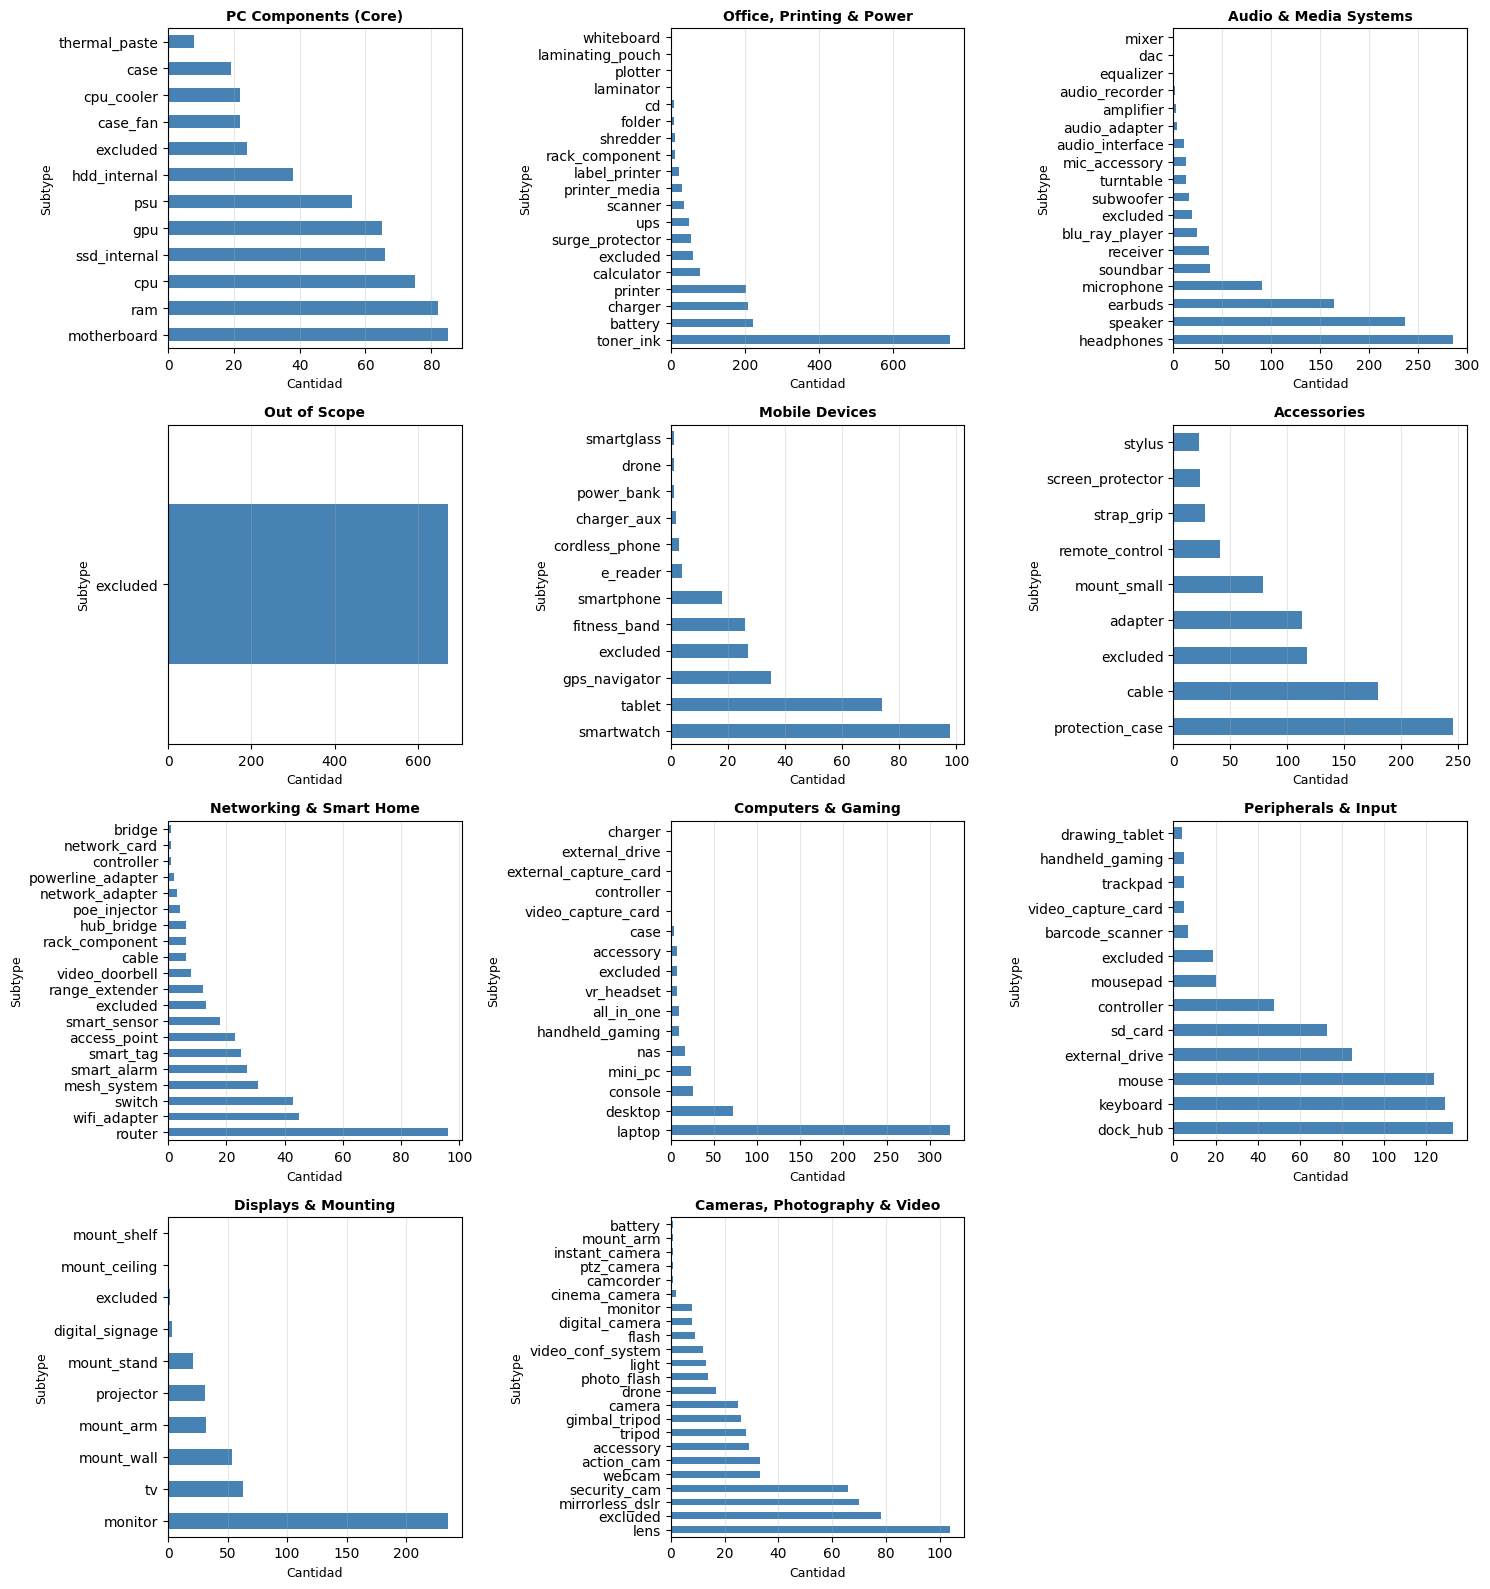

In [158]:
import matplotlib.pyplot as plt

# Obtener todas las categorías únicas
categorias = df['category'].unique()

# Crear un dashboard con subplots en grid de 3 columnas
num_cols = 3
num_rows = (len(categorias) + num_cols - 1) // num_cols  # Redondea hacia arriba

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4*num_rows))
axes = axes.flatten()  # Convierte a array 1D para iterar fácilmente

# Iterar sobre cada categoría y crear una gráfica
for idx, categoria in enumerate(categorias):
    # Calcular los conteos
    subtype_counts = df[df['category'] == categoria]['subtype'].value_counts()

    # --- CORRECCIÓN AQUÍ ---
    # Si no hay datos (la serie está vacía), ocultamos el eje y saltamos al siguiente
    if subtype_counts.empty:
        axes[idx].set_visible(False)
        print(f"⚠️ Aviso: La categoría '{categoria}' no tiene subtipos válidos (posibles NaNs).")
        continue
    # -----------------------

    subtype_counts.plot(kind='barh', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{categoria}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Cantidad', fontsize=9)
    axes[idx].set_ylabel('Subtype', fontsize=9)
    axes[idx].grid(axis='x', alpha=0.3)

# Ocultar los subplots sobrantes (si el grid es más grande que las categorías)
for idx in range(len(categorias), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [85]:
total_excluded = ((df['subtype'] == 'excluded') & (df['category'] != 'Out of Scope')).sum()
porcentaje = (total_excluded / len(df)) * 100

print(f"📊 Total de productos 'excluded': {total_excluded}")
print(f"📉 Representan el {porcentaje:.2f}% de tu dataset total.")

📊 Total de productos 'excluded': 408
📉 Representan el 5.31% de tu dataset total.


In [242]:
# 1. Carga tus datos (ajusta los nombres de tus archivos)
df_specs = pd.read_csv('amazon_specs_combined.csv')
df_prices = pd.read_csv('../../Datasets/amazon_final.csv')

# 2. Une ambos datasets (usando el ID o el Título como llave)
df_final = pd.merge(
    df_specs, 
    df_prices, 
    left_on='original_title', 
    right_on='product_title'
)

# 3. Revertir el log1 para ver el precio real
# Si usaste log natural (ln(1+x)):
df_final['price_real'] = np.exp(df_final['log_original_price']) - 1

# Si usaste log base 10 (log10(1+x)):
# df['price_real'] = (10 ** df['log1_price']) - 1

# 4. Filtrar por la categoría Accesorios y ordenar por precio de mayor a menor
expensive_accessories = df_final[(df_final['category'] == 'Displays & Mounting') & (df_final['subtype'] == 'monitor')].sort_values(by='price_real', ascending=True).iloc[0:700]
# 5. Mostrar el Top 20
print("AUDITORÍA DE ACCESORIOS CAROS:")

# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample_peripherals = expensive_accessories[['original_title', 'subtype', 'price_real', 'product_image_url']]

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

AUDITORÍA DE ACCESORIOS CAROS:


,original_title,subtype,price_real,product_image_url
4394,"MSI PRO MP225V, 22-inch, 1920 x 1080 (FHD) Computer Monitor, 100Hz, Adaptive-Synch, HDMI, Video Port, Low Blue Light, Eye-Q Check, VESA Mountable, Tilt, 1ms, Black",monitor,64.34,
121,"Philips 22 inch Class Thin Full HD (1920 x 1080) Monitor, 100Hz Refresh Rate, VESA, HDMI x1, VGA x1, LowBlue Mode, Adaptive Sync, 4 Year Advance Replacement Warranty, 221V8LB",monitor,67.20,
1008,Sceptre New 22-inch Professional Monitor HDMI x2 Build-in Speakers 2025,monitor,68.97,
6775,"Dell E2423H 23.8"" Full HD LED LCD Monitor - 16:9",monitor,79.68,
7627,"RCA 10.1"" WiFi Digital Picture Frame Uhale App Photo Frames Electronic HD IPS Touch Screen Display with 32GB Memory LED Lights, Support USB/SD Card, Slideshow, Instantly Share Photos Videos",monitor,79.99,
7234,LG 27MS500-B 27 inch IPS Computer Monitor FHD (1920x1080) 100Hz 5ms Reader Mode Borderless Design OnScreen Control Black Stabilizer DAS Crosshair HDMI Black,monitor,79.99,
3551,"ASUS BE24EQK 23.8” Business Monitor with 1080P Full HD IPS, Eye Care, DisplayPort HDMI, Frameless, Built-in Adjustable 2MP Webcam, Mic Array, Stereo speaker, Video Conference,BLACK",monitor,89.76,
856,"ViewSonic VA2447-MH 24 Inch Full HD 1080p Monitor with 100Hz, FreeSync, Ultra-Thin Bezel, Eye Care, HDMI, VGA Inputs for Home and Office",monitor,89.99,
2484,"ViewSonic VA1653 16 Inch 1080p FHD IPS Portable Monitor with Eye Care, Built-in Stand, USB C, Mini HDMI, and Protective Case External Second Screen for Laptops, PC, Mac, and Gaming Consoles",monitor,89.99,
629,"HP 27h Full HD Monitor - Diagonal - IPS Panel & 75Hz Refresh Rate - Smooth Screen - 3-Sided Micro-Edge Bezel - 100mm Height/Tilt Adjust - Built-in Dual Speakers - for Hybrid Workers,Black",monitor,92.99,


In [240]:
import pandas as pd


# 1. Carga tus datos (ajusta los nombres de tus archivos)
df_specs = pd.read_csv('amazon_specs_combined.csv')
df_prices = pd.read_csv('../../Datasets/amazon_final.csv')

# 2. Une ambos datasets (usando el ID o el Título como llave)
df_final = pd.merge(
    df_specs, 
    df_prices, 
    left_on='original_title', 
    right_on='product_title'
)

# 3. Revertir el log1 para ver el precio real
# Si usaste log natural (ln(1+x)):
df_final['price_real'] = np.exp(df_final['log_original_price']) - 1

# Si usaste log base 10 (log10(1+x)):
# df['price_real'] = (10 ** df['log1_price']) - 1

# 4. Filtrar por la categoría Accesorios y ordenar por precio de mayor a menor
# filtrar categoría y quedarse solo con subtypes con menos de 50 apariciones
subset = df_final[df_final['category'] == 'Displays & Mounting']
subtype_counts = subset['subtype'].value_counts()
rare_subtypes = subtype_counts[subtype_counts < 69].index
expensive_accessories = subset[subset['subtype'].isin(rare_subtypes)].sort_values(by='subtype', ascending=False).iloc[0:700]
# 5. Mostrar el Top 20
print("AUDITORÍA DE ACCESORIOS CAROS:")

# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample_peripherals = expensive_accessories[['original_title', 'subtype', 'price_real', 'product_image_url']]

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

AUDITORÍA DE ACCESORIOS CAROS:


,original_title,subtype,price_real,product_image_url
58,"VIZIO 40-inch Full HD 1080p Smart TV with DTS Virtual: X, Alexa Compatibility, Google Cast Built-in, Bluetooth Headphone Capable, (VFD40M-08 New)",tv,169.99,
2531,"Sony 50-Inch Class 4K Ultra HD BRAVIA 3 LED Smart TV with Google TV, Dolby Vision HDR, and Exclusive Features for PlayStation®5 (K-50S30)",tv,528.00,
6780,"SAMSUNG 65-Inch Class OLED 4K S90C Series Quantum HDR, Dolby Atmos Object Tracking Sound Lite, Ultra Thin, Q-Symphony 3.0, Gaming Hub, Smart TV with Alexa Built-in (QN65S90C, 2023 Model), Titan Black",tv,1064.94,
1811,"TCL 55-Inch Class NXTVISION Series QLED 4K UHD Google Smart TV Canvas Style Art Frame TV - QLED, 120hz, Matte Anti-Glare Screen, Free Bezel and Frame, Atmos, Free Art Included (55A300W, 2024 Model)",tv,629.99,
1908,"Westinghouse 32 Inch TV, HD LED Small Flat Screen Non-Smart Television, Works with Fire Stick, Roku, Apple TV, TiVo, Xumo, and Streaming Devices",tv,149.99,
6728,"Roku Smart TV 2025 – 55-Inch Pro Series, Mini-LED TV – RokuTV with Backlit Voice Remote Pro – Flat Screen 4K QLED Television with 120Hz Refresh Rate & Dolby Vision IQ, Live News, Sports, Entertainment",tv,699.99,
6722,"Panasonic W70 Series (2025 Model) 43"" LED 4K Ultra HD Smart Fire TV, Press & Ask Alexa, Apple AirPlay, HDR10+, HDMI 2.1, and Bluetooth Support - 43W70BP",tv,252.02,
6648,"VIZIO 24"" Inches VHD24M-0810 Class V-Series HD (1080p) Smart LED TV - Full Array Backlighting, Smart TV with Apple AirPlay, Chromecast, Alexa Compatibility (Renewed)",tv,98.00,
2159,"Hisense 55"" Class U8 Mini-LED ULED 4K UHD Google Smart TV (55U8QG, 2025 Model) - QLED, Native 165Hz, VRR 288, Up to LD5600, 5000 Nits, HDR10+, Dolby Vision IQ · Atmos, IMAX Enhanced, 4.1.2 Ch Audio",tv,878.99,
6601,"VIZIO 50 Inch 4K Smart TV, V-Series UHD LED HDR Television with Apple AirPlay and Chromecast Built-in",tv,295.85,


In [234]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
FILE_PATH = "amazon_specs_combined.csv"

# Pega aquí los títulos EXACTOS que quieres mover (usa comillas triples para evitar problemas)
TITLES_TO_MOVE = [
    """Elgato Wave Desk Stand - Adjustable Mounting Arm for Microphones, Works, HyperX, Rode, Fifine, Shure and More Mics, Compatible 1/4, 3/8 & 5/8 Thread, for Recording/Podcasting/Streaming"""
    
]

def move_to_printer():
    print(f"📂 Cargando {FILE_PATH}...")
    
    if not os.path.exists(FILE_PATH):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(FILE_PATH)
    
    # 1. FILTRAR POR LA LISTA DE TÍTULOS
    # Usamos isin() para buscar si el título está en nuestra lista
    mask = df['original_title'].isin(TITLES_TO_MOVE)
    
    count = mask.sum()
    
    if count == 0:
        print("⚠️ No se encontró ninguno de los títulos indicados.")
        print("Asegúrate de que sean idénticos (espacios, comas, etc).")
        return

    print(f"🔄 Se han encontrado {count} productos. Moviendo a 'Office' -> 'printer'...")

    # 2. ACTUALIZAR CATEGORÍA Y SUBTIPO
    df.loc[mask, 'category'] = 'Displays & Mounting'
    df.loc[mask, 'subtype'] = 'mount_stand'

    # 3. GUARDAR
    df.to_csv(FILE_PATH, index=False)
    
    print(f"✅ ¡Hecho! Archivo actualizado.")
    # Mostramos los cambios para confirmar
    print(df.loc[mask, ['original_title', 'category', 'subtype']])

move_to_printer()

📂 Cargando amazon_specs_combined.csv...
🔄 Se han encontrado 1 productos. Moviendo a 'Office' -> 'printer'...
✅ ¡Hecho! Archivo actualizado.
                                         original_title             category  \
4877  Elgato Wave Desk Stand - Adjustable Mounting A...  Displays & Mounting   

          subtype  
4877  mount_stand  


In [248]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
FILE_PATH = "amazon_specs_combined.csv"

# Pega aquí el título EXACTO que quieres borrar (cuidado con espacios al final)
TITLE_TO_REMOVE = 'Atomos Ninja 5.2" 4K HDMI Recording Monitor'
def delete_by_title_string():
    print(f"📂 Cargando {FILE_PATH}...")
    
    if not os.path.exists(FILE_PATH):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(FILE_PATH)
    initial_count = len(df)
    
    # 1. BUSCAR EL TÍTULO EXACTO
    # Creamos una máscara booleana donde el título coincida exactamente
    mask = df['original_title'] == TITLE_TO_REMOVE
    
    # Obtenemos las filas que coinciden
    rows_to_delete = df[mask]
    
    if rows_to_delete.empty:
        print(f"⚠️ No se encontró ninguna fila con el título exacto:\n'{TITLE_TO_REMOVE}'")
        print("Consejo: Verifica espacios extra o signos de puntuación.")
        return

    # 2. MOSTRAR Y CONFIRMAR
    print(f"\n🗑️ Se han encontrado {len(rows_to_delete)} filas con ese título. Eliminando...")
    
    # Mostramos los índices que se van a borrar por si acaso
    for idx in rows_to_delete.index:
        print(f"   ❌ Borrando índice {idx}...")

    # 3. ELIMINAR (Hacemos drop usando los índices que encontramos)
    df = df.drop(rows_to_delete.index)

    # 4. GUARDAR
    df.to_csv(FILE_PATH, index=False)
    
    print(f"\n✅ ¡Hecho! Archivo actualizado.")
    print(f"📊 Antes: {initial_count} -> Ahora: {len(df)} filas.")


delete_by_title_string()

📂 Cargando amazon_specs_combined.csv...

🗑️ Se han encontrado 1 filas con ese título. Eliminando...
   ❌ Borrando índice 7336...

✅ ¡Hecho! Archivo actualizado.
📊 Antes: 7643 -> Ahora: 7642 filas.


In [239]:
import pandas as pd
import os

# --- CONFIGURACIÓN ---
INPUT_FILE = "amazon_specs_combined.csv"  # Tu archivo actual
OUTPUT_FILE = "amazon_specs_combined.csv"   # El archivo nuevo corregido

def fix_airpods():
    print(f"📂 Cargando {INPUT_FILE}...")
    
    if not os.path.exists(INPUT_FILE):
        print("❌ Error: No encuentro el archivo.")
        return

    df = pd.read_csv(INPUT_FILE)
    
    # 1. IDENTIFICAR LOS PRODUCTOS A MOVER
    filtro_airpods = (df['category'] == 'Displays & Mounting') & (df['subtype'] == 'digital_signage')
    
    count = filtro_airpods.sum()
    print(f"🔍 Detectados {count} productos mal clasificados como 'earbuds' en Mobile Devices.")

    if count == 0:
        print("✅ No hay nada que corregir. Todo parece estar bien.")
        return
    

    # 3. CAMBIAR CATEGORÍA Y SUBTIPO
    print("🏷️ Actualizando etiquetas de categoría y subtipo...")
    df.loc[filtro_airpods, 'category'] = 'Displays & Mounting'
    df.loc[filtro_airpods, 'subtype'] = 'excluded'
    # 4. GUARDAR
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"🎉 ¡Éxito! Archivo corregido guardado como: {OUTPUT_FILE}")
    
fix_airpods()

📂 Cargando amazon_specs_combined.csv...
🔍 Detectados 3 productos mal clasificados como 'earbuds' en Mobile Devices.
🏷️ Actualizando etiquetas de categoría y subtipo...
🎉 ¡Éxito! Archivo corregido guardado como: amazon_specs_combined.csv
